# Qubit Experiments - Standardized Demo (DEMO_v2)

This notebook is reorganized from `DEMO.ipynb`, covering the following 10 experimental procedures. All timing parameters (pulse width / trigger period / delay) are kept identical to the original version:

1. AWG Continuous Output (signal calibration)
2. AWG Time-Domain Capture (TraceIQ)
3. Phase Sweep
4. Resonator Spectroscopy (S21 Sweep)
5. Qubit Spectroscopy (Two-Tone)
6. Flux-Dependent Qubit Spectroscopy
7. Time Rabi (Rabi Oscillation)
8. Power Rabi
9. T1 (Energy Relaxation)
10. T2* Ramsey (Free Induction Decay)

**Usage order**: first run `0. Environment Setup` -> `1. Device Init & Sync`, after which any experiment cell can be executed independently.

## 0. Environment Setup

Import dependencies, clear shared memory, configure the Matplotlib backend.

In [59]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw

SHARED_DEVICE_MEM.clear_ip()

def generate_gaussian_pulse(freq, t, fs, delay=0, rise_time_ratio=0.15):
    """
    Generate a full Gaussian pulse (envelope is zero at both ends, no flat top).
    freq: carrier frequency
    t: total pulse duration (s)
    fs: sample rate (Hz)
    delay: lag (reserved, unused)
    rise_time_ratio: reserved, unused
    """
    num_points = round(t * fs)
    time_line = np.linspace(0, t, num_points, endpoint=False)
    center = t / 2
    std = t / 6                                              # 99.7% energy within +/-3 sigma, both ends ~0
    envelope = np.exp(-0.5 * ((time_line - center) / std) ** 2)
    carrier = np.sin(2 * np.pi * freq * time_line)
    wave = envelope * carrier
    return wave

%matplotlib widget


## 1. Device Init & Sync

- MCI (`device`) outputs the 10 MHz reference clock; QSYNC (`qsync`) receives it.
- Open order: QSYNC -> MCI -> `sync_system`, so the system is aligned only after the reference clock is stable.
- `MixMode` 1 / 2 select the DA first / second Nyquist zone respectively.

In [60]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

device: None无法连接 timed out
device: None无法连接 [WinError 10061] 由于目标计算机积极拒绝，无法连接。
device: None无法连接 [WinError 10061] 由于目标计算机积极拒绝，无法连接。
device: None无法连接 [WinError 10061] 由于目标计算机积极拒绝，无法连接。
device: None无法连接 [WinError 10061] 由于目标计算机积极拒绝，无法连接。
device: None无法连接 [WinError 10061] 由于目标计算机积极拒绝，无法连接。
[WinError 10061] 由于目标计算机积极拒绝，无法连接。


TypeError: object of type 'bool' has no len()

## 2. AWG Continuous Output (signal calibration)

Continuously triggered sine-wave output, useful for calibrating external instruments such as power meters / spectrum analyzers.
`shots = 0xFFFFFFFF` means unlimited triggering; call `qsync.set('ResetTrig')` in the last cell to stop.

In [39]:
# ---------- Channel and signal parameters ----------
drive_ch    = "S13-O1"          # drive output channel
drive_freq  = 100e6             # output frequency (Hz)
drive_width = 5e-6              # single-segment waveform duration (s)
drive_amp   = 1.0               # normalized amplitude
drive_delay = 48e-9             # channel output delay, must align to 16 ns (3 x 16 ns)
trig_period = 100e-6            # qsync trigger period (s)
shots       = 0xFFFFFFFF        # continuous trigger (~unlimited)

# ---------- Waveform generation and download ----------
time_array = np.linspace(0, drive_width, round(drive_width * da_rate_xy), endpoint=False)
wave = drive_amp * np.sin(2 * np.pi * drive_freq * time_array)

device.set("Waveform", wave, drive_ch)
device.set("Delay", drive_delay, drive_ch)

# ---------- Start continuous triggering ----------
qsync.set("Shot", int(shots))
qsync.set("GenerateTrig", trig_period)


In [40]:
# Stop AWG continuous triggering
qsync.set("ResetTrig")


## 3. AWG Time-Domain Capture (Play & Capture 1us cos wave)

The readout channel emits a 1 us cosine pulse; the AD channel samples 2 us in raw time-domain (TraceIQ) mode. Multi-shot averages are plotted as the time-domain envelope.

In [41]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


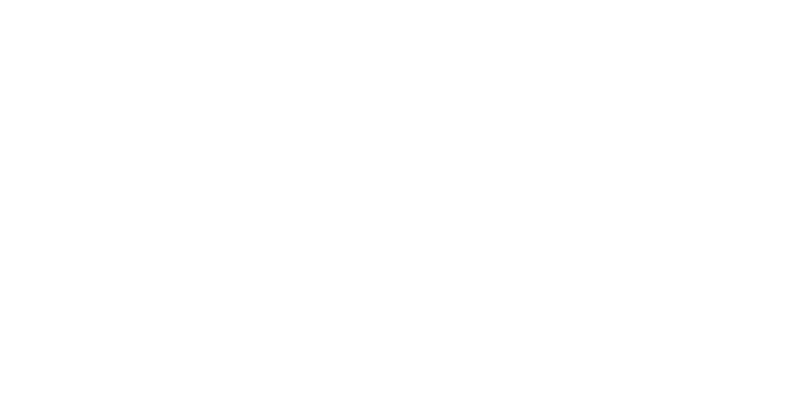

In [42]:
# ---------- Channel and capture parameters ----------
probe_out_ch    = "S2-O1"
probe_in_ch     = "S2-I1"
probe_freq      = 100e6
probe_out_width = 1e-6              # output pulse duration (s)
probe_in_width  = 2e-6              # AD sampling duration (s)
probe_in_delay  = 32e-9             # AD trigger delay (s)
shots           = 64
trig_period     = 100e-6
capture_mode    = 1                 # time-domain capture mode

# ---------- Waveform generation ----------
time_array = np.linspace(0, probe_out_width, round(probe_out_width * da_rate_rd), endpoint=False)
wave = np.sin(2 * np.pi * probe_freq * time_array)

# ---------- Device configuration ----------
device.set("CaptureMode", capture_mode)
device.set("Shot", shots)
device.set("TimeWidth", probe_in_width, probe_in_ch)
device.set("TriggerDelay", probe_in_delay, probe_in_ch)
device.set("Waveform", wave, probe_out_ch)

qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

# ---------- Trigger capture ----------
device.set("StartCapture")
qsync.set("GenerateTrig")
trace_data = device.get("TraceIQ", probe_in_ch)

# ---------- Data processing and plotting ----------
ad_time_array = np.linspace(0, probe_in_width, round(probe_in_width * ad_rate), endpoint=False)
trace_avg = np.asarray(trace_data).mean(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(ad_time_array * 1e6, trace_avg)
plt.xlabel("AD Sample Time (µs)")
plt.ylabel("Amplitude")
plt.title("AWG Play & Capture (TraceIQ)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Phase Sweep (Phase Stability Test)

Sweep the initial phase of the output cosine at a fixed frequency, recording the demodulated IQ complex values. If the hardware phase is stable, the scatter should distribute uniformly on the unit circle.

In [43]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   2,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


Phase sweep:   0%|          | 0/19 [00:00<?, ?it/s]

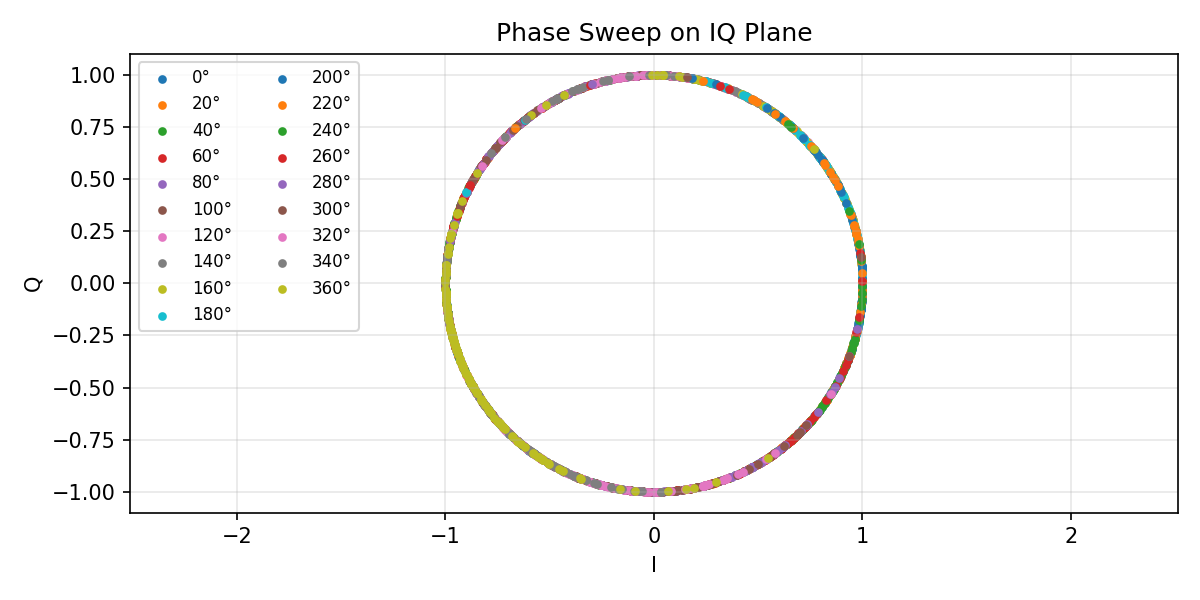

In [44]:
# ---------- Channel and sweep parameters ----------
probe_out_ch   = "S2-O1"
probe_in_ch    = "S2-I1"
probe_freq     = 4.3e9                 # signal frequency (Hz)
probe_width    = 4.6e-6                # output waveform duration (s)
probe_in_width = 2e-6                  # IN sampling time window (s)
probe_in_delay = 410e-9                # IN trigger delay (s)
shots          = 128
trig_period    = 50e-6
phase_list     = np.linspace(0, 360, 19)   # phases to sweep (deg)

# ---------- Static device configuration ----------
device.set("CaptureMode", 0)                                # IQ demodulation mode
device.set("Shot", shots)
device.set("TimeWidth", probe_in_width, probe_in_ch)
device.set("TriggerDelay", probe_in_delay, probe_in_ch)
qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

time_array = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)

# ---------- Phase sweep capture ----------
phase_iq_list = []
plt.figure(figsize=(8, 4), dpi=150)
for phase_deg in tqdm(phase_list, desc="Phase sweep"):
    wave = np.cos(2 * np.pi * probe_freq * time_array + np.deg2rad(phase_deg))
    device.set("Waveform", wave, probe_out_ch)
    device.set("FreqList", [float(probe_freq)], probe_in_ch)
    device.set("StartCapture")
    qsync.set("GenerateTrig")

    iq = np.asarray(device.get("IQ", probe_in_ch))
    iq_norm = (iq / np.abs(iq)).T                # normalize onto the unit circle
    I, Q = iq_norm.real, iq_norm.imag
    phase_iq_list.append([I, Q])
    plt.scatter(I, Q, s=10, label=f"{phase_deg:.0f}°")

# ---------- Plotting ----------
plt.axis("equal")
plt.xlabel("I")
plt.ylabel("Q")
plt.title("Phase Sweep on IQ Plane")
plt.grid(True, alpha=0.3)
plt.legend(prop={"size": 8}, loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


## 5. Resonator Spectroscopy (S21 Sweep)

- The readout channel (`probe_out_ch`) emits a series of cosine probe pulses at different frequencies;
- The capture channel (`probe_in_ch`) is configured with matching demodulation frequencies to perform hardware IQ demodulation;
- Multi-shot averages are taken to compute |S21|, yielding the resonator spectral response (resonance peak).

In [45]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   2,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.2
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


S21 sweep:   0%|          | 0/201 [00:00<?, ?it/s]

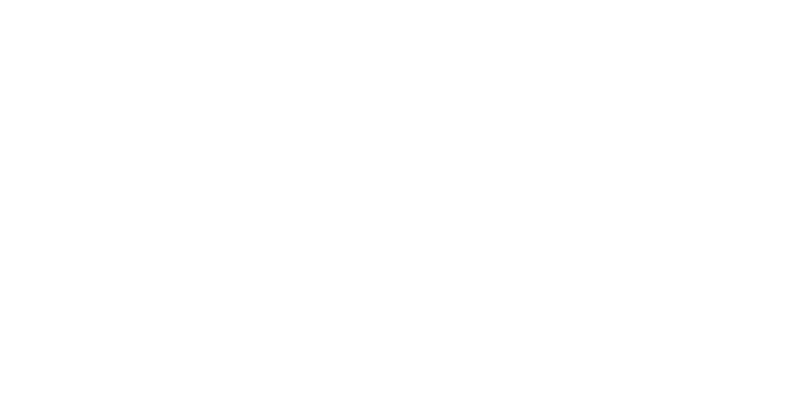

In [46]:
# ---------- 1. Channel and sweep parameters ----------
probe_out_ch    = "S2-O1"                       # probe pulse output channel
probe_in_ch     = "S2-I1"                       # probe signal capture channel
probe_freq_list = np.linspace(4.1e9, 6e9, 201)   # sweep frequency list (Hz)
probe_width     = 2e-6                          # probe pulse duration (s)
probe_out_delay = 0                             # output delay (s)
probe_in_delay  = 0                             # readout delay (s)                              
probe_amp       = 1.0                           # probe pulse amplitude (normalized)
shots           = 64                            # averages per frequency point
trig_period     = 500e-6                        # qsync trigger period (s)

# ---------- 2. Static device configuration ----------
time_array = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)

device.set("Shot", shots)                            # number of shots on capture side
device.set("TimeWidth", probe_width, probe_in_ch)    # IN-channel capture time window
device.set("Delay", probe_out_delay, probe_out_ch)   # OUT-channel output delay
device.set("INDelay", probe_in_delay, probe_in_ch)   # IN-channel input delay
qsync.set("Shot", shots)                             # number of shots on trigger side
qsync.set("TrigPeriod", trig_period)                 # trigger period

# ---------- 3. Frequency sweep capture ----------
s21_iq_list = []
for probe_freq in tqdm(probe_freq_list, desc="S21 sweep"):
    wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_array)
    device.set("Waveform", wave, probe_out_ch)                # download probe waveform
    device.set("FreqList", [float(probe_freq)], probe_in_ch)  # configure demodulation frequency
    device.set("StartCapture")                                # start capture
    qsync.set("GenerateTrig")                                 # fire trigger
    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    s21_iq_list.append(iq_data)

# ---------- 4. Data processing and plotting ----------
s21_complex  = np.array(s21_iq_list).mean(axis=1)             # average over the shot dimension
s21_power_db = 20 * np.log10(np.abs(s21_complex))             # amplitude to dB

plt.figure(figsize=(8, 4))
plt.plot(probe_freq_list / 1e6, s21_power_db, marker="o")
plt.xlabel("Probe Frequency (MHz)")
plt.ylabel("|S21| (dB)")
plt.title("Cavity S21 Sweep")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Qubit Spectroscopy (Two-Tone)

Sweep the XY drive frequency at a fixed readout frequency: an XY pulse first modifies the qubit state, then a readout pulse acquires the demodulated result. |S21| dips when the XY frequency is near the qubit transition frequency.

In [47]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


Spectrum:   0%|          | 0/201 [00:00<?, ?it/s]

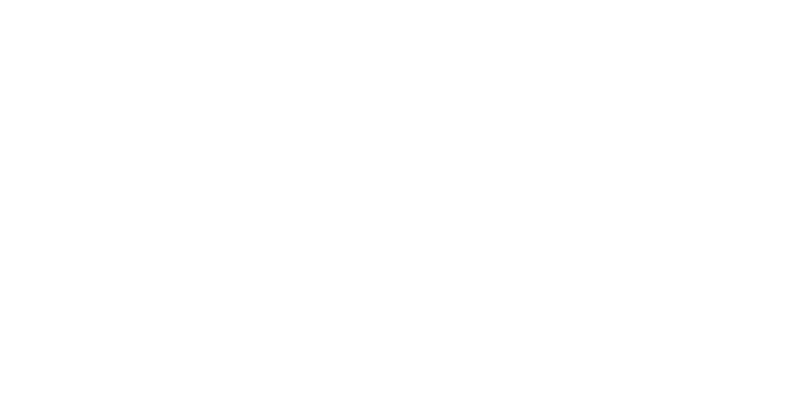

In [48]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch        = "S13-O1"
probe_out_ch = "S2-O1"
probe_in_ch  = "S2-I1"
probe_freq   = 40e6
probe_width  = 2e-6
drive_width  = 2e-6
xy_amp       = 1.0
probe_amp    = 1.0
shots        = 64
trig_period  = 500e-6
xy_freq_list = np.linspace(4e6, 100e6, 201)
probe_in_delay      = drive_width + 400e-9           # probe capture delay = end of drive + 400 ns
probe_out_delay     = drive_width + 200e-9          # probe playback delay = end of drive + 200 ns

# ---------- 2. Probe waveform ----------
probe_time_array = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)
probe_wave       = np.cos(2 * np.pi * probe_freq * probe_time_array)

# ---------- 3. Static device configuration ----------
device.set("Shot", shots)
device.set("Waveform", probe_wave, probe_out_ch)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)
device.set("Delay", probe_in_delay, probe_out_ch)
device.set("INDelay", probe_out_delay, probe_in_ch)
qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

# ---------- 4. Frequency sweep capture ----------
spectrum_iq_list = []
for xy_freq in tqdm(xy_freq_list, desc="Spectrum"):
    xy_wave = xy_amp * generate_gaussian_pulse(xy_freq, drive_width, da_rate_xy)
    device.set("Waveform", xy_wave, xy_ch)
    device.set("StartCapture")
    qsync.set("GenerateTrig")
    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    spectrum_iq_list.append(iq_data)

# ---------- 5. Data processing and plotting ----------
spectrum_complex = np.array(spectrum_iq_list).mean(axis=1)
spectrum_db      = 20 * np.log10(np.abs(spectrum_complex))

plt.figure(figsize=(8, 4))
plt.plot(xy_freq_list / 1e6, spectrum_db, marker="o")
plt.xlabel("XY Drive Frequency (MHz)")
plt.ylabel("|S21| (dB)")
plt.title("Qubit Spectrum")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Flux-Dependent Qubit Spectroscopy

2D sweep: outer loop scans Z bias (flux), inner loop scans XY frequency. Plotting the 2D flux spectrum reveals how the qubit transition frequency changes topologically with flux.

In [49]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


Flux sweep:   0%|          | 0/20 [00:00<?, ?it/s]

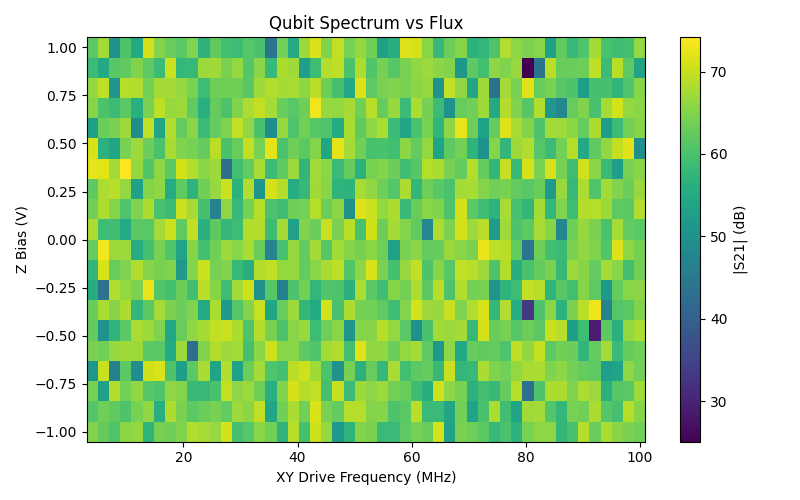

In [50]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch        = "S13-O1"
z_ch         = "S15-O1"           # alternatively "S12-O1" (high-speed Z)
probe_out_ch = "S2-O1"
probe_in_ch  = "S2-I1"
probe_freq   = 40e6
probe_width  = 1e-6
drive_width  = 1e-6
xy_amp       = 1.0
probe_amp    = 1.0
shots        = 64
trig_period  = 500e-6
xy_freq_list = np.linspace(4e6, 100e6, 50)
bias_list    = np.linspace(-1, 1, 20)
z_margin     = 96e-9                                  # Z margin reserved before/after XY (16 ns aligned)
z_width      = drive_width + 2 * z_margin             # total Z bias duration, fully envelopes XY drive
xy_delay     = z_margin                               # XY starts z_margin after Z begins
probe_out_delay = 2 * z_margin + drive_width + 100e-9             # probe playback delay = end of XY drive
probe_in_delay  = probe_out_delay + 400e-9            # probe capture delay = probe playback + 400 ns

# ---------- 2. Probe waveform ----------
probe_time_array = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)
probe_wave       = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time_array)

# ---------- 3. Static device configuration ----------
device.set("Shot", shots)
device.set("Waveform", probe_wave, probe_out_ch)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)
device.set("Delay", xy_delay, xy_ch)
device.set("Delay", probe_out_delay, probe_out_ch)
device.set("INDelay", probe_in_delay, probe_in_ch)
qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

# ---------- 4. 2D sweep capture ----------
spectrum_2d = []
for bias in tqdm(bias_list, desc="Flux sweep"):
    z_wave = bias * np.ones(round(da_rate_ll * z_width))       # square-wave Z bias (z_margin added before/after)
    z_wave[-1] = 0                                             # zero last sample to avoid DC residue
    device.set("Waveform", z_wave, z_ch)

    spectrum_row = []
    for xy_freq in xy_freq_list:
        xy_wave = xy_amp * generate_gaussian_pulse(xy_freq, drive_width, da_rate_xy)
        device.set("Waveform", xy_wave, xy_ch)
        device.set("StartCapture")
        qsync.set("GenerateTrig")
        iq_data = np.asarray(device.get("IQData", probe_in_ch))
        spectrum_row.append(iq_data)
    spectrum_2d.append(spectrum_row)

# ---------- 5. Data processing and plotting ----------
spectrum_2d_arr     = np.array(spectrum_2d)                           # (bias, freq, shot, n_demod=1)
spectrum_2d_complex = spectrum_2d_arr.mean(axis=2).squeeze(-1)        # -> (bias, freq)
spectrum_2d_db      = 20 * np.log10(np.abs(spectrum_2d_complex))

plt.figure(figsize=(8, 5))
plt.pcolormesh(xy_freq_list / 1e6, bias_list, spectrum_2d_db,
               shading="auto", cmap="viridis")
plt.colorbar(label="|S21| (dB)")
plt.xlabel("XY Drive Frequency (MHz)")
plt.ylabel("Z Bias (V)")
plt.title("Qubit Spectrum vs Flux")
plt.tight_layout()
plt.show()


## 8. Time Rabi (Rabi Oscillation)

Sweep the XY pulse width and observe the qubit-state oscillation versus drive duration (Rabi oscillation).
At each step, both the readout output delay `Delay` and the IN capture delay `INDelay` are adjusted so that the probe falls right after the end of the drive.

In [51]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


Time Rabi:   0%|          | 0/100 [00:00<?, ?it/s]

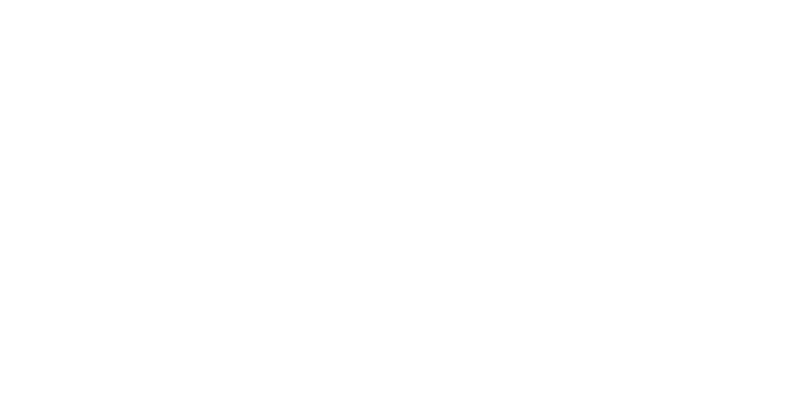

In [52]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch         = "S13-O1"
z_ch          = "S15-O1"
probe_out_ch  = "S2-O1"
probe_in_ch   = "S2-I1"
probe_freq    = 40e6
xy_freq       = 40e6
probe_width   = 1e-6
xy_amp        = 1.0
probe_amp     = 1.0
bias          = 1.0
shots         = 64
trig_period   = 500e-6
xy_width_list = np.linspace(1e-6, 4e-6, 100)        # XY pulse-width sweep
z_margin      = 96e-9                               # Z margin reserved before/after XY (16 ns aligned)
xy_delay      = z_margin                            # XY starts z_margin after Z begins

# ---------- 2. Static device configuration ----------
device.set("Shot", shots)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)
device.set("Delay", xy_delay, xy_ch)
qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

probe_time_array = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)
probe_wave       = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time_array)
device.set("Waveform", probe_wave, probe_out_ch)

# ---------- 3. Time sweep capture ----------
rabi_iq_list = []
for xy_width in tqdm(xy_width_list, desc="Time Rabi"):
    # XY drive waveform (Gaussian-envelope modulated)
    xy_wave = xy_amp * generate_gaussian_pulse(xy_freq, xy_width, da_rate_xy)
    device.set("Waveform", xy_wave, xy_ch)

    # Z bias waveform (z_margin added before/after, fully envelopes XY)
    z_width = xy_width + 2 * z_margin
    z_wave  = bias * np.ones(round(da_rate_ll * z_width))
    z_wave[-1] = 0
    device.set("Waveform", z_wave, z_ch)

    # Adjust readout / capture delay so it follows immediately after the drive
    device.set("Delay",   2 * xy_delay + xy_width + 100e-9,    probe_out_ch)
    device.set("INDelay", 2 * xy_delay + xy_width + 400e-9,    probe_in_ch)

    device.set("StartCapture")
    qsync.set("GenerateTrig")
    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    rabi_iq_list.append(iq_data)

# ---------- 4. Data processing and plotting ----------
rabi_complex = np.array(rabi_iq_list).mean(axis=1)
rabi_db      = 20 * np.log10(np.abs(rabi_complex))

plt.figure(figsize=(8, 4))
plt.plot(xy_width_list * 1e6, rabi_db, marker="o", markersize=3)
plt.xlabel("XY Pulse Width (µs)")
plt.ylabel("|S21| (dB)")
plt.title("Time Rabi")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Power Rabi

With XY pulse width fixed, sweep its amplitude and observe how the Rabi oscillation changes with drive power.
_Note: the original DEMO mistakenly used `time_range` on the x-axis; here it is corrected to `xy_amp_list`._

In [53]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


Power Rabi:   0%|          | 0/101 [00:00<?, ?it/s]

C:\Users\sn06452\AppData\Local\Temp\ipykernel_13664\2009479219.py:56: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 4))


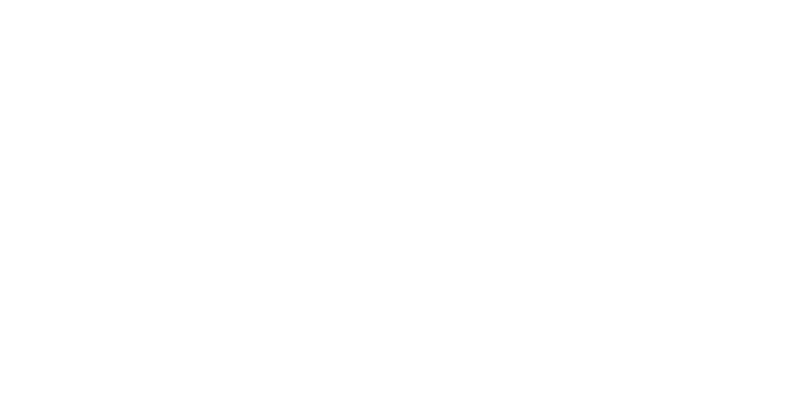

In [54]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch        = "S13-O1"
z_ch         = "S15-O1"
probe_out_ch = "S2-O1"
probe_in_ch  = "S2-I1"
probe_freq   = 40e6
xy_freq      = 40e6
probe_width  = 1e-6
drive_width  = 1e-6
probe_amp    = 1.0
bias         = 1.0
shots        = 64
trig_period  = 500e-6
xy_amp_list  = np.linspace(0, 1, 101)                # XY amplitude sweep
z_margin     = 96e-9                                 # Z margin reserved before/after XY (16 ns aligned)
z_width      = drive_width + 2 * z_margin            # total Z bias duration, fully envelopes XY drive
xy_delay     = z_margin                              # XY starts z_margin after Z begins
probe_out_delay = 2 * z_margin + drive_width +100e-9             # probe playback delay = end of XY drive
probe_in_delay  = probe_out_delay + 400e-9           # probe capture delay = probe playback + 400 ns

# ---------- 2. Static device configuration ----------
device.set("Shot", shots)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)
device.set("Delay", xy_delay, xy_ch)
device.set("Delay", probe_out_delay, probe_out_ch)
device.set("INDelay", probe_in_delay, probe_in_ch)
qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

# Probe waveform (fixed)
probe_time_array = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)
probe_wave       = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time_array)
device.set("Waveform", probe_wave, probe_out_ch)

# Z bias waveform (fixed, z_margin added before/after)
z_wave = bias * np.ones(round(da_rate_ll * z_width))
z_wave[-1] = 0
device.set("Waveform", z_wave, z_ch)

# ---------- 3. Amplitude sweep capture ----------
xy_pulse_unit = generate_gaussian_pulse(xy_freq, drive_width, da_rate_xy)
rabi_iq_list = []
for xy_amp in tqdm(xy_amp_list, desc="Power Rabi"):
    xy_wave = xy_amp * xy_pulse_unit
    device.set("Waveform", xy_wave, xy_ch)
    device.set("StartCapture")
    qsync.set("GenerateTrig")
    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    rabi_iq_list.append(iq_data)

# ---------- 4. Data processing and plotting ----------
rabi_complex = np.array(rabi_iq_list).mean(axis=1)
rabi_db      = 20 * np.log10(np.abs(rabi_complex))

plt.figure(figsize=(8, 4))
plt.plot(xy_amp_list, rabi_db, marker="o", markersize=3)
plt.xlabel("XY Amplitude (a.u.)")
plt.ylabel("|S21| (dB)")
plt.title("Power Rabi")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. T1 (Energy Relaxation)

Apply a pi pulse to excite the qubit to |1>, wait `wait_time`, then read out. Sweeping the wait time yields an exponential decay; fitting gives T1.

In [55]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


T1:   0%|          | 0/101 [00:00<?, ?it/s]

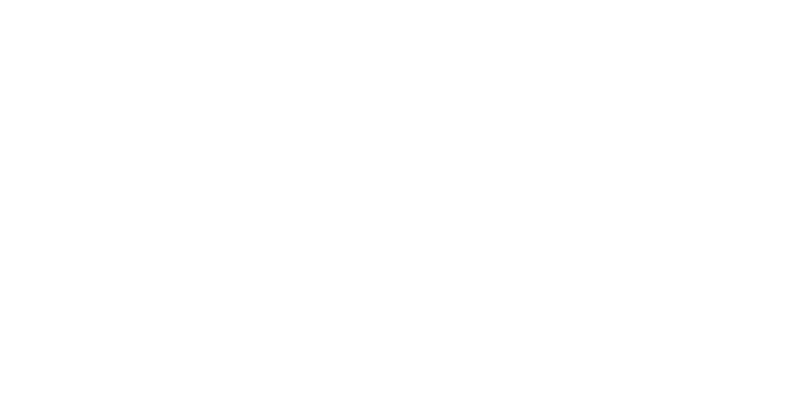

In [56]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch          = "S13-O1"
z_ch           = "S15-O1"
probe_out_ch   = "S2-O1"
probe_in_ch    = "S2-I1"
probe_freq     = 40e6
xy_freq        = 40e6
probe_width    = 1e-6
drive_width    = 1e-6                         # pi pulse width
xy_amp         = 1.0
probe_amp      = 1.0
bias           = 1.0
shots          = 64
trig_period    = 500e-6
wait_time_list = np.linspace(0, 4e-6, 101)    # wait-time sweep after pi pulse
z_margin       = 96e-9                        # Z margin reserved before/after pi pulse (16 ns aligned)
z_width        = drive_width + 2 * z_margin   # total Z bias duration, fully envelopes the pi pulse
xy_delay       = z_margin                     # XY starts z_margin after Z begins

# ---------- 2. Static device configuration ----------
device.set("Shot", shots)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)
device.set("Delay", xy_delay, xy_ch)
qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

# pi pulse (fixed)
xy_wave = xy_amp * generate_gaussian_pulse(xy_freq, drive_width, da_rate_xy)
device.set("Waveform", xy_wave, xy_ch)

# Probe waveform (fixed)
probe_time_array = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)
probe_wave       = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time_array)
device.set("Waveform", probe_wave, probe_out_ch)

# Z bias (fixed, z_margin added before/after)
z_wave = bias * np.ones(round(da_rate_ll * z_width))
z_wave[-1] = 0
device.set("Waveform", z_wave, z_ch)

# ---------- 3. Wait-time sweep ----------
t1_iq_list = []
for wait_time in tqdm(wait_time_list, desc="T1"):
    device.set("Delay",   2 * xy_delay + drive_width + wait_time,             probe_out_ch)
    device.set("INDelay", 2 * xy_delay + drive_width + wait_time + 400e-9,    probe_in_ch)

    device.set("StartCapture")
    qsync.set("GenerateTrig")
    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    t1_iq_list.append(iq_data)

# ---------- 4. Data processing and plotting ----------
t1_complex = np.array(t1_iq_list).mean(axis=1)
t1_db      = 20 * np.log10(np.abs(t1_complex))

plt.figure(figsize=(8, 4))
plt.plot(wait_time_list * 1e6, t1_db, marker="o", markersize=3)
plt.xlabel("Wait Time (µs)")
plt.ylabel("|S21| (dB)")
plt.title("T1 Decay")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
time.sleep(1)

## 11. T2* Ramsey (Free Induction Decay)

Ramsey sequence: pi/2 - tau - pi/2. Sweep the interval tau between the two pi/2 pulses; the envelope decay gives T2*. Wait step is aligned to 16 ns.

In [57]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"

# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 13.2
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


T2 Ramsey:   0%|          | 0/251 [00:00<?, ?it/s]

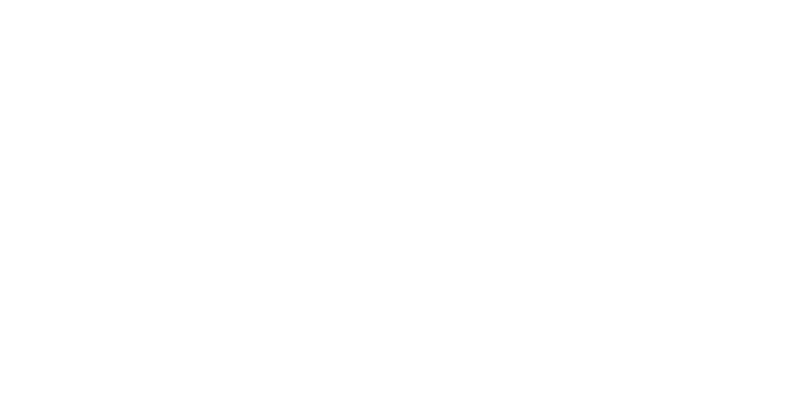

In [58]:
# ---------- 1. Channel and sweep parameters ----------
xy_ch          = "S13-O1"
z_ch           = "S15-O1"
probe_out_ch   = "S2-O1"
probe_in_ch    = "S2-I1"
probe_freq     = 40e6
xy_freq        = 40e6
probe_width    = 1e-6
xy_pulse_width = 0.5e-6                                  # pi/2 pulse width
xy_amp         = 1.0
probe_amp      = 1.0
bias           = 1.0
shots          = 64
trig_period    = 500e-6
wait_step      = 16e-9                                   # 16 ns alignment
wait_time_list = np.arange(0, 4e-6 + 0.5 * wait_step, wait_step)
z_margin       = 96e-9                                   # Z margin reserved before/after XY sequence (16 ns aligned)
xy_delay       = z_margin                                # XY starts z_margin after Z begins

# ---------- 2. Static device configuration ----------
device.set("Shot", shots)
device.set("TimeWidth", probe_width, probe_in_ch)
device.set("FreqList", [float(probe_freq)], probe_in_ch)
device.set("Delay", xy_delay, xy_ch)
qsync.set("Shot", shots)
qsync.set("TrigPeriod", trig_period)

# Probe waveform (fixed)
probe_time_array = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)
probe_wave       = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time_array)
device.set("Waveform", probe_wave, probe_out_ch)

# pi/2 pulse template (reused)
xy_pulse       = xy_amp * generate_gaussian_pulse(xy_freq, xy_pulse_width, da_rate_xy)
pulse_samples  = len(xy_pulse)

# ---------- 3. Interval-time sweep ----------
t2_iq_list = []
for wait_time in tqdm(wait_time_list, desc="T2 Ramsey"):
    gap_samples   = round(wait_time * da_rate_xy)
    total_samples = 2 * pulse_samples + gap_samples
    xy_wave = np.zeros(total_samples)
    xy_wave[:pulse_samples] = xy_pulse
    xy_wave[pulse_samples + gap_samples:] = xy_pulse
    device.set("Waveform", xy_wave, xy_ch)

    total_xy_width = total_samples / da_rate_xy

    # Z bias spans the total drive duration (z_margin before/after, fully envelopes the XY sequence)
    z_width = total_xy_width + 2 * z_margin
    z_wave  = bias * np.ones(round(da_rate_ll * z_width))
    z_wave[-1] = 0
    device.set("Waveform", z_wave, z_ch)

    # readout / capture delays follow the end of the drive
    device.set("Delay",   2 * xy_delay + total_xy_width + 100e-9,    probe_out_ch)
    device.set("INDelay", 2 * xy_delay + total_xy_width + 400e-9,    probe_in_ch)

    device.set("StartCapture")
    qsync.set("GenerateTrig")
    iq_data = np.asarray(device.get("IQData", probe_in_ch))
    t2_iq_list.append(iq_data)

# ---------- 4. Data processing and plotting ----------
t2_complex = np.array(t2_iq_list).mean(axis=1)
t2_db      = 20 * np.log10(np.abs(t2_complex))

plt.figure(figsize=(8, 4))
plt.plot(wait_time_list * 1e6, t2_db, marker="o", markersize=3)
plt.xlabel("Wait Time τ (µs)")
plt.ylabel("|S21| (dB)")
plt.title("T2 Ramsey")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
